#Final Project
Sadaf khan

Load Dataset

In [1]:
import pandas as pd
df_news_final_project = pd.read_parquet('https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet', engine='pyarrow')
df_news_final_project.shape



(199989, 5)

In [2]:
df_news_final_project

,url,date,language,title,text
0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod..."
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,\n\nThis AI video of gymnastics might be the f...
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","\n\nIf using AI feels like a chore, try this -..."
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation M...
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers ...
...,...,...,...,...,...
199984,https://www.zawya.com/en/press-release/compani...,2025-10-13,en,Ejada Systems signs MoU with Dyna.Ai to enhanc...,Ejada Systems signs MoU with Dyna.Ai to enhanc...
199985,https://www.zawya.com/en/press-release/compani...,2025-03-13,en,UNDP and e& strengthen AI collaboration for su...,UNDP and e& strengthen AI collaboration for su...
199986,https://www.zawya.com/en/press-release/events-...,2025-06-05,en,Harnessing AI to make energy poverty history: ...,Harnessing AI to make energy poverty history: ...
199987,https://www.zdnet.com/article/reddit-will-star...,2023-04-19,en,Reddit will start charging some users for API ...,\n\n\nReddit will start charging some users fo...


In [3]:
df_news_final_project.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199989 entries, 0 to 199988
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       199989 non-null  object
 1   date      199989 non-null  object
 2   language  199989 non-null  object
 3   title     199989 non-null  object
 4   text      199989 non-null  object
dtypes: object(5)
memory usage: 7.6+ MB


Duplicate Article Detection
```
```



In [4]:
df_news_final_project.duplicated().sum()


np.int64(0)

In [5]:
df_news_final_project.duplicated(subset='text').sum()


np.int64(494)

Language Verification

In [6]:
df_news_final_project['language'].value_counts()


,count
language,
en,199989


missing values assessment



In [7]:
df_news_final_project.isnull().sum()


,0
url,0
date,0
language,0
title,0
text,0


text length analysis

In [8]:
#Creating Text Length Feature and Summary Statistics
df_news_final_project['text_length'] = df_news_final_project['text'].str.len()
df_news_final_project['text_length'].describe()


,text_length
count,199989.000000
mean,9098.766462
std,7264.733714
min,21.000000
25%,5245.000000
50%,7622.000000
75%,11390.000000
max,580772.000000


In [9]:
#Examining Extreme Percentiles
df_news_final_project['text_length'].quantile([0.01, 0.05, 0.95, 0.99])


,text_length
0.01,867.00
0.05,1466.40
0.95,19415.60
0.99,33832.04


In [10]:
#Checking Maximum Text Length
df_news_final_project['text_length'].max()


580772

In [11]:
#Creating Working Copy of Dataset
df = df_news_final_project.copy()


In [12]:
df = df.drop_duplicates(subset='text')


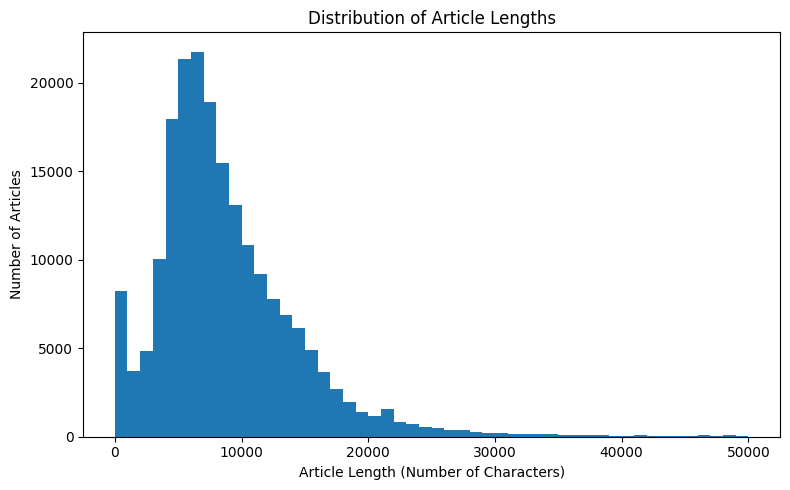

In [24]:
import matplotlib.pyplot as plt

# Histogram of article lengths (limit extreme outliers)
plt.figure(figsize=(8,5))

plt.hist(
    df_news_final_project['text_length'],
    bins=50,
    range=(0, 50000)   # limit range so extreme outliers don't distort the plot
)

plt.title("Distribution of Article Lengths")
plt.xlabel("Article Length (Number of Characters)")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()

Temporal Distribution of Articles


In [13]:
df['year'] = pd.to_datetime(df['date']).dt.year
df['year'].value_counts().sort_index()


,count
year,
2022,18320
2023,71255
2024,49642
2025,54208
2026,6070


Removing Extremely Short and Long Articles






In [14]:
df['text_length'] = df['text'].str.len()

df = df[
    (df['text_length'] > 800) &
    (df['text_length'] < 100000)
]


In [15]:
#Final Dataset Size After Cleaning
df.shape


(197895, 7)

In [16]:
#Defining AI-Specific Keywords
impact_terms = [
    "automate","automation","replace","replacing","augment","augmentation","productivity",
    "efficiency","workflow","redesign","cost reduction","reduce costs","layoff","job loss",
    "adoption","rollout","deployment","implementation","governance","compliance","regulation"
]

ai_terms = [
    "artificial intelligence"," ai ","machine learning"," ml ",
    "generative ai","llm","gpt","agent"
]

#Constructing a Rule-Based Relevance Scoring Function
def relevance_score(t):
    t = t.lower()
    score = 0
    score += sum(1 for w in ai_terms if w in t)
    score += sum(1 for w in impact_terms if w in t)
    return score

#Computing Relevance Scores for All Articles
df["rel_score"] = df["text"].apply(relevance_score)
df["rel_score"].describe()


,rel_score
count,197895.000000
mean,4.047636
std,2.524534
min,0.000000
25%,2.000000
50%,4.000000
75%,5.000000
max,25.000000


In [17]:
df['rel_score'].value_counts().sort_index().head()


,count
rel_score,
0,3235
1,23394
2,31996
3,37158
4,32379


In [18]:
#Filtering to AI Impact-Relevant Subset
df_rel = df[df["rel_score"] >= 3].copy()
df_rel.shape


(139270, 8)

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
# Saving Cleaned and Filtered Dataset
df_rel.to_parquet("/content/drive/MyDrive/NLP final project/df_rel.parquet", index=False)


In [21]:
df_rel.shape


(139270, 8)

In [22]:
df_rel.columns


Index(['url', 'date', 'language', 'title', 'text', 'text_length', 'year',
       'rel_score'],
      dtype='object')

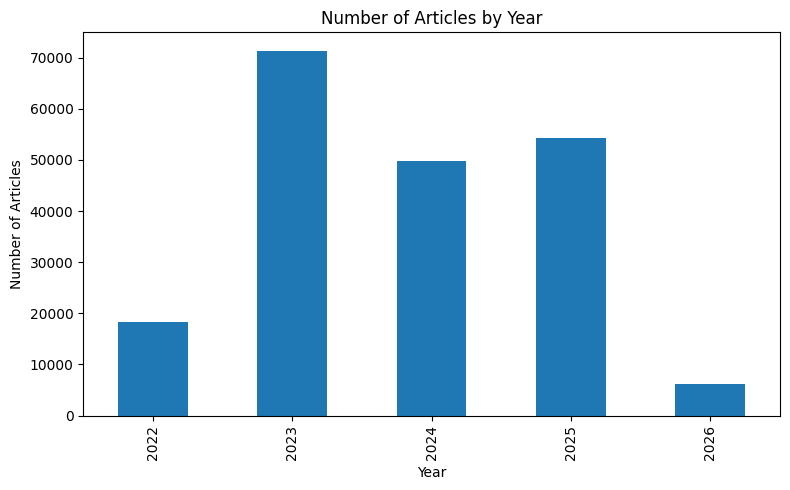

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# extract year
df_news_final_project['year'] = pd.to_datetime(df_news_final_project['date']).dt.year

# count articles per year
year_counts = df_news_final_project['year'].value_counts().sort_index()

# plot
plt.figure(figsize=(8,5))
year_counts.plot(kind='bar')
plt.title("Number of Articles by Year")
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.tight_layout()
plt.show()